   start_year  n_trials
0        2000        61
1        2001        60
2        2002        73
3        2003        65
4        2004        86
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   start_year  25 non-null     int64
 1   n_trials    25 non-null     int64
dtypes: int64(2)
memory usage: 528.0 bytes
None


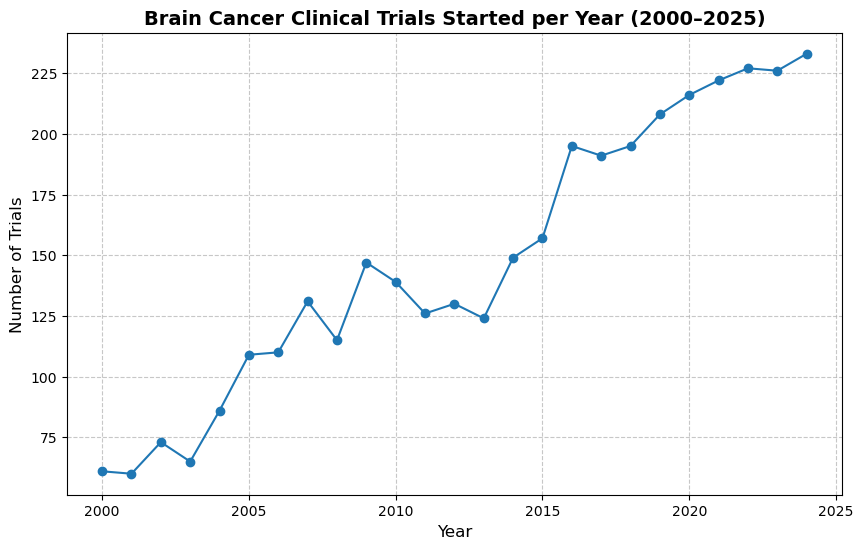

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9,6),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",     # keep title bold
    "axes.labelsize": 12,
    "axes.labelweight": "normal",   # axis labels normal
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": False,             # no grid
    "legend.fontsize": 10,
    "legend.frameon": False
})


# 1. Load your exported CSV
df = pd.read_excel("Downloads/q1_test_export.xlsx")

# 2. Inspect
print(df.head())
print(df.info())

# 3. Basic line chart, select the columns from the DF and add a title.
plt.figure(figsize=(10,6))
plt.plot(df["start_year"], df["n_trials"], marker="o")
plt.title("Brain Cancer Clinical Trials Started per Year (2000–2025)")
plt.xlabel("Year")
plt.ylabel("Number of Trials")
plt.grid(True)
plt.show()

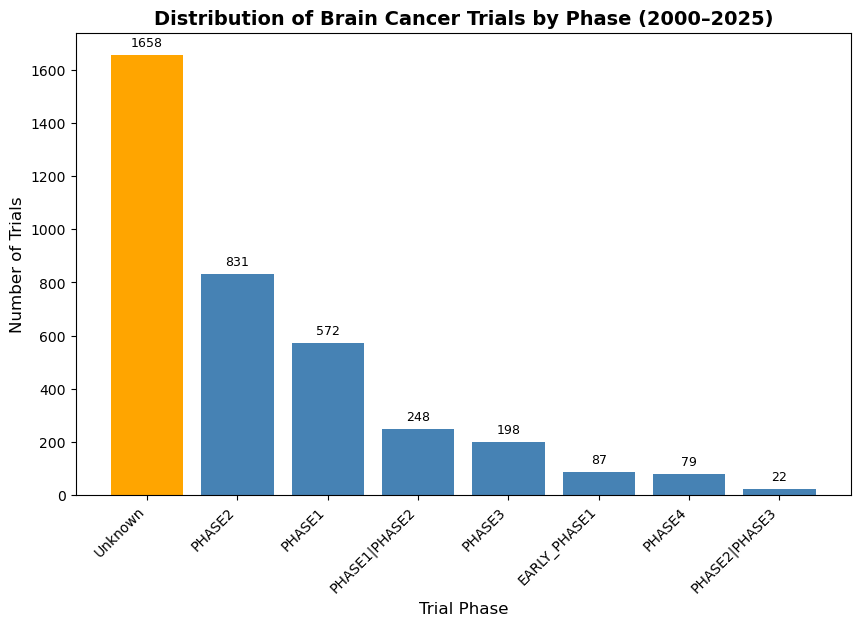

In [55]:
df = pd.read_csv("Downloads/n_trials_per_phase.csv")

# highlight Unknown in orange, others in steelblue
colors = ["orange" if phase == "Unknown" else "steelblue" for phase in df["clean_phases"]]

plt.figure(figsize=(10,6))
plt.bar(df["clean_phases"], df["n_trials"], color=colors)
plt.title("Distribution of Brain Cancer Trials by Phase (2000–2025)")
plt.xlabel("Trial Phase")
plt.ylabel("Number of Trials")
plt.xticks(rotation=45, ha="right")

# annotate the bars with counts
for i, val in enumerate(df["n_trials"]):
    plt.text(i, val + 20, str(val), ha="center", va="bottom", fontsize=9)

plt.show()


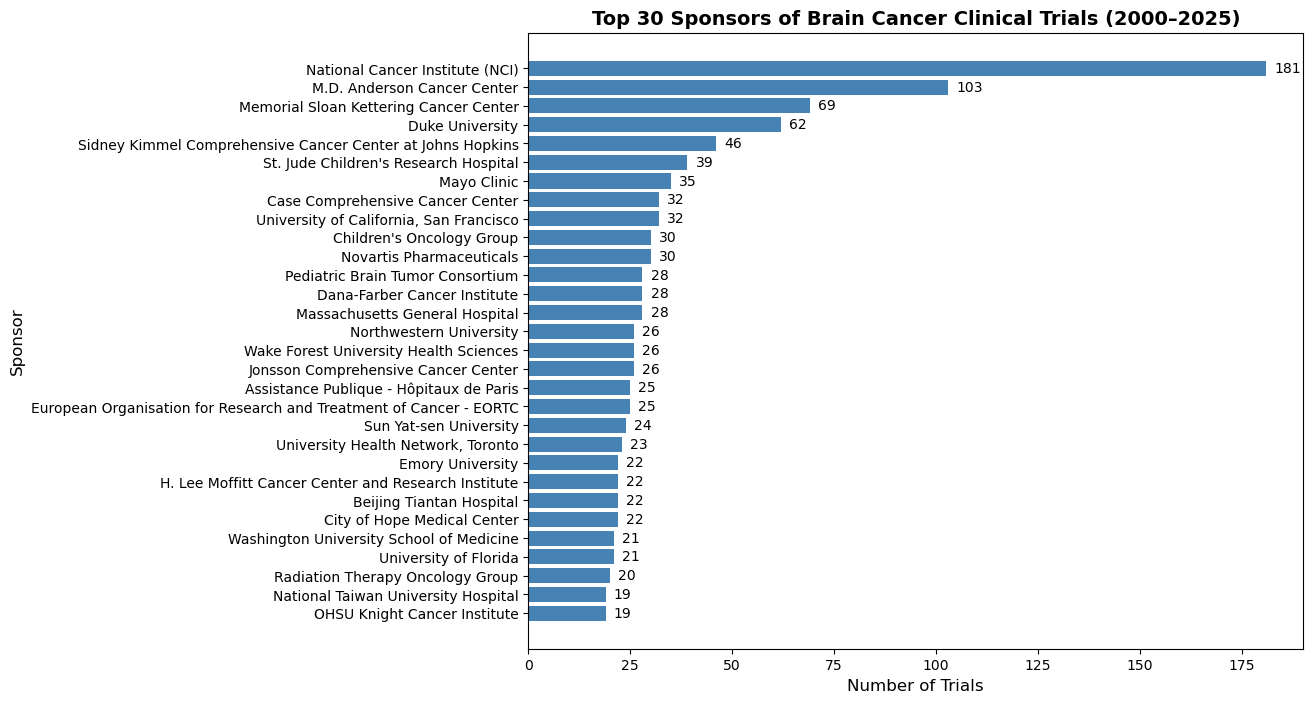

In [56]:
# Q3. Who are the main sponsors of clinical trials for brain cancer?

# looking at the field, there are 1176 rows, meaning 1176 individual sponsors of these brain cancer trials. Lets limit it to say the top 30.

df = pd.read_csv("Downloads/q3_sponsors_data.csv")

# lets grab only the top 30 contributors
df_top30 = df.sort_values("number_of_studies_sponsored", ascending=False).head(30)

plt.figure(figsize=(10,8))
plt.barh(df_top30["clean_sponsor"], df_top30["number_of_studies_sponsored"], color="steelblue")

plt.title("Top 30 Sponsors of Brain Cancer Clinical Trials (2000–2025)")
plt.xlabel("Number of Trials")
plt.ylabel("Sponsor")
plt.gca().invert_yaxis()   # make the biggest sponsor at the top.

for i, v in enumerate(df_top30["number_of_studies_sponsored"]):
    plt.text(v + 2, i, str(v), va="center")


plt.show()

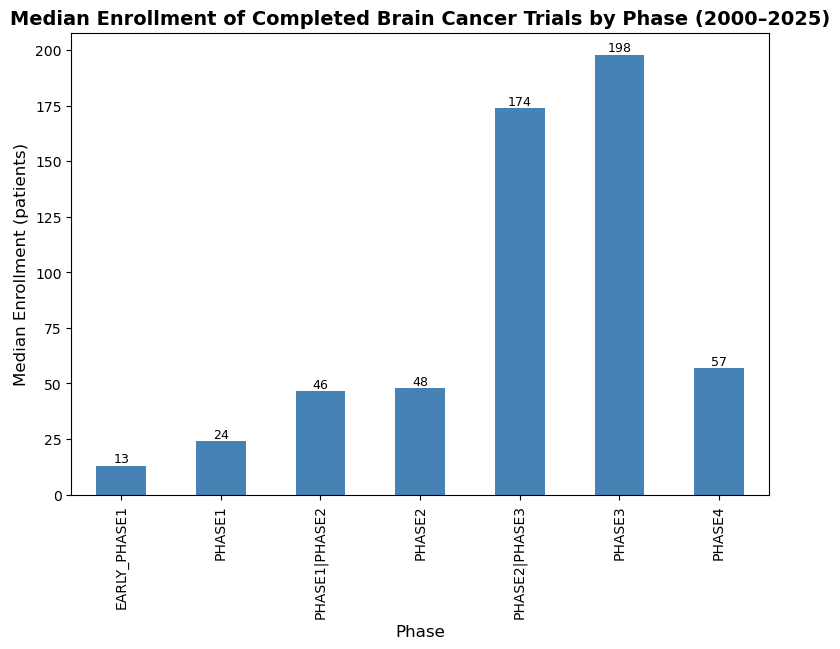

In [57]:
# What was the median enrollment size for a successful clinical trial per phase. 

df_complete = pd.read_excel("Downloads/complete_trials_by_phase.xlsx")

phase_order = [
    "Unknown",
    "EARLY_PHASE1",
    "PHASE1",
    "PHASE1|PHASE2",
    "PHASE2",
    "PHASE2|PHASE3",
    "PHASE3",
    "PHASE4"
]

# Reorder the dataframe
df_complete["clean_phase"] = pd.Categorical(
    df_complete["clean_phase"],
    categories=phase_order,
    ordered=True
)
df_complete = df_complete.sort_values("clean_phase")

# drop unknown, its not informative and just messes up the visualisation
df_no_unknown = df_complete[df_complete["clean_phase"] != "Unknown"]


ax = df_no_unknown.plot(
    x="clean_phase",
    y="median_enrollment",
    kind="bar",
    figsize=(9,6),
    legend=False,
    color="steelblue"
)

ax.set_title("Median Enrollment of Completed Brain Cancer Trials by Phase (2000–2025)")
ax.set_ylabel("Median Enrollment (patients)")
ax.set_xlabel("Phase")

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=9
    )



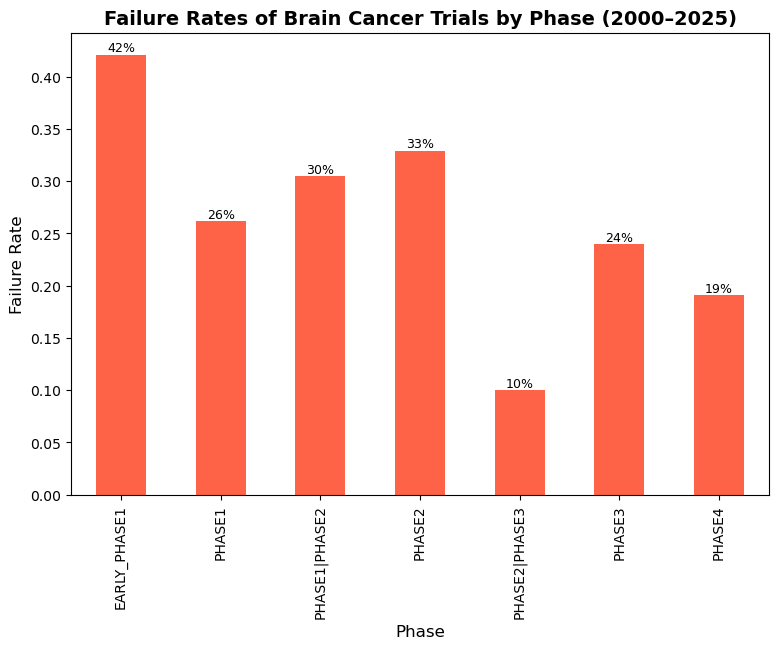

In [59]:
# Here we visualise the plot for failure rate by phase, to get an idea of the attrition rates by phase.

df_failure = pd.read_csv("Downloads/failure_vs_success_by_phase.csv")

phase_order = [
    "EARLY_PHASE1",
    "PHASE1",
    "PHASE1|PHASE2",
    "PHASE2",
    "PHASE2|PHASE3",
    "PHASE3",
    "PHASE4",
    "Unknown"
]

df_failure["clean_phase"] = pd.Categorical(
    df_failure["clean_phase"],
    categories=phase_order,
    ordered=True
)
df_failure = df_failure.sort_values("clean_phase")

df_failure_no_unknown = df_failure[df_failure["clean_phase"] != "Unknown"]


ax = df_failure_no_unknown.plot(
    x="clean_phase",
    y="fail_rate",
    kind="bar",
    figsize=(9,6),
    legend=False,
    color="tomato"
)

ax.set_title("Failure Rates of Brain Cancer Trials by Phase (2000–2025)")
ax.set_ylabel("Failure Rate")
ax.set_xlabel("Phase")


# Add percentage labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.0%}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center", va="bottom", fontsize=9
    )




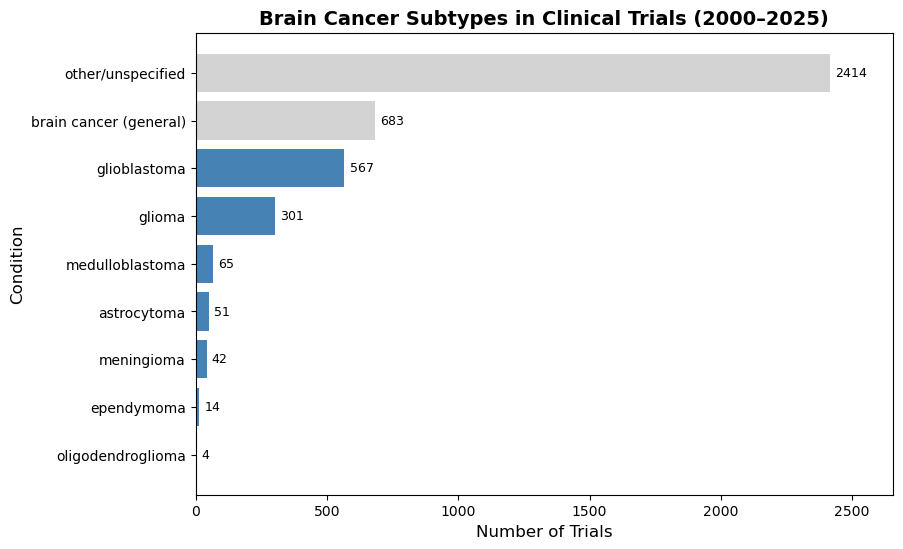

In [65]:
df_conditions = pd.read_csv("Downloads/brain_cancer_condition_groups.csv")

df_conditions = df_conditions.sort_values("n_trials", ascending=True)

colors = [
    "lightgray" if cond in ["other/unspecified", "brain cancer (general)"] 
    else "steelblue" 
    for cond in df_conditions["condition_group"]
]

plt.figure(figsize=(9,6))
plt.barh(df_conditions["condition_group"], df_conditions["n_trials"], color=colors)

plt.title("Brain Cancer Subtypes in Clinical Trials (2000–2025)", fontsize=14, fontweight="bold")
plt.xlabel("Number of Trials", fontsize=12)
plt.ylabel("Condition", fontsize=12)

# Add value labels
for i, val in enumerate(df_conditions["n_trials"]):
    plt.text(val + 20, i, str(val), va="center", fontsize=9)

plt.xlim(0, df_conditions["n_trials"].max() * 1.1)

plt.show()


